In [1]:
# DASHBOARD NOTEBOOK
# Libraries
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import runpy
import re
import gc

# GENERAL PARAMETERS
RAW_ROOT =  Path("data/raw_signal")
RAW_EMG_DIR   = RAW_ROOT / "emg"
RAW_BIA_DIR   = RAW_ROOT / "bia"
RAW_NIRS_DIR  = RAW_ROOT / "nirs"
RAW_MYOTON_DIR = RAW_ROOT / "myoton"

## LABELING PARAMETERS
# PROTOCOLE SEQUENCE ORDER 
SEQ_ORDER = "INIT WU REST0 MVC_REF REST1 SVC_REF REST2 EX_DYN REST3 MVC_RECOV_DYN REST4 EX_STA REST5 MVC_RECOV_STA END".split()




## 0. SUBJECT SELECTION

In [2]:

# RUN_ID = "011BeSa_20251023" # reexport- missing seq in master
# RUN_ID = "081PaFe_20251113" # reexport -missing seq in master
# RUN_ID = "487LePa_20251003" 
# RUN_ID = "092MaLe_20251031" 
RUN_ID = "101SaCl_20251127" # OK
# RUN_ID = "133DeMa_20251021" 
# RUN_ID = "197LaAl_20251016" 
# RUN_ID = "209CeJa_20251105" 
# RUN_ID = "222SoMa_20251113" 
# RUN_ID = "261PoLe_20251128" 
# RUN_ID = "284ChGe_20251030" 
# RUN_ID = "307BeJa_20251103" 
# RUN_ID = "314DuHu_20251009" 
# RUN_ID = "374SaSa_20251030" 
# RUN_ID = "394ZoMo_20251114" 
# RUN_ID = "402RaAx_20251128" 
# RUN_ID = "444BoAl_20251104" 
# RUN_ID = "459PoQu_20251020" 
# RUN_ID = "500TeJo_20251114" 
# RUN_ID = "592RiNa_20251028" 
# RUN_ID = "622PiSt_20251104" 
# RUN_ID = "684LuSh_20251013" 
# RUN_ID = "743MoGi_20251103" 
# RUN_ID = "797BoAm_20251021" 
# RUN_ID = "802BlHu_20251028" 
# RUN_ID = "923AoMo_20251017" 
# RUN_ID = "997FuLu_20251112" 
# RUN_ID = "890PeTh_20251023" 

########

#PATH
PARTICIPANTS_DIR = Path("data/participants")  

# SET UP CACHE PATHS PARAMETERS
BASE_DERIVED = Path("data/derived") / RUN_ID
CACHE_DIR = BASE_DERIVED / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True) #create cache directory if it doesn't exist

# SET UP INITIAL CONTEXT CELL (CTX)
# CONTEXT  CELL

CTX = {
    # identity / paths
    "RUN_ID": RUN_ID,
    "CACHE_DIR": CACHE_DIR,
    "TORQUE_COL": "torque_raw",
}

## 1. PARTICIPANT INFO LOADER

In [ ]:
# 01 - PARTICIPANTS
import importlib
from sources import _01_participant
importlib.reload(_01_participant)

participants_df = _01_participant.run_participant(
    ctx=CTX,
    participants_dir=PARTICIPANTS_DIR,
    CACHE_DIR=CACHE_DIR,
    force_recompute=True,
)

CTX["participants_df"] = participants_df
participants_df

[01_participants] Loading participant Excel for RUN_ID=101SaCl_20251127 (key=101SaCl)
[01_participants] Successfully loaded participant sheet: 101SaCl_20251127_Infos.xlsx


,file,participant_id,dob,sex,height_cm,mass_kg,dominant_side,practice_level,patho_history,medication,run_number,mvc_ref,delsys_ts_init,comments
0,101SaCl_20251127_Infos.xlsx,101SaCl,2005-09-09,F,163.0,55.0,G,STAPS PF\nForce athlétique - 1 an - 1 à 3x / s...,RAS,RAS,3222,231,2025-11-27 11:06:51.360,NaN


## 2. EMG LOADER

In [4]:
# 02 - EMG IMPORT (function-based)

import importlib
from sources import _02_emg_import
importlib.reload(_02_emg_import)

master_index_grid, emg_compact_df, torque_compact_df, ts_ref = _02_emg_import.run_emg_import(
    ctx=CTX,
    raw_emg_dir=RAW_EMG_DIR,
    run_id=RUN_ID,
    participants_df=participants_df,
    force_recompute=False,
)

# fill ctx for downstream
CTX["master_index_grid"] = master_index_grid
CTX["emg_compact_df"] = emg_compact_df
CTX["torque_compact_df"] = torque_compact_df
CTX["ts_ref"] = ts_ref

[02_emg_import] Cached outputs to :
 data\derived\101SaCl_20251127\cache\02_master_index_grid.parquet, 
data\derived\101SaCl_20251127\cache\02_emg_compact.parquet, 
data\derived\101SaCl_20251127\cache\02_torque_compact.parquet


## 03. LABELLING SEQUENCES

[03a_sequence_picker] Please select the different sequences boundaries (left clic on the torque plot BEFORE and AFTER each sequences). 
 Once done, move to the next cell. 
 Plot title must display 14/14 boundaries picked


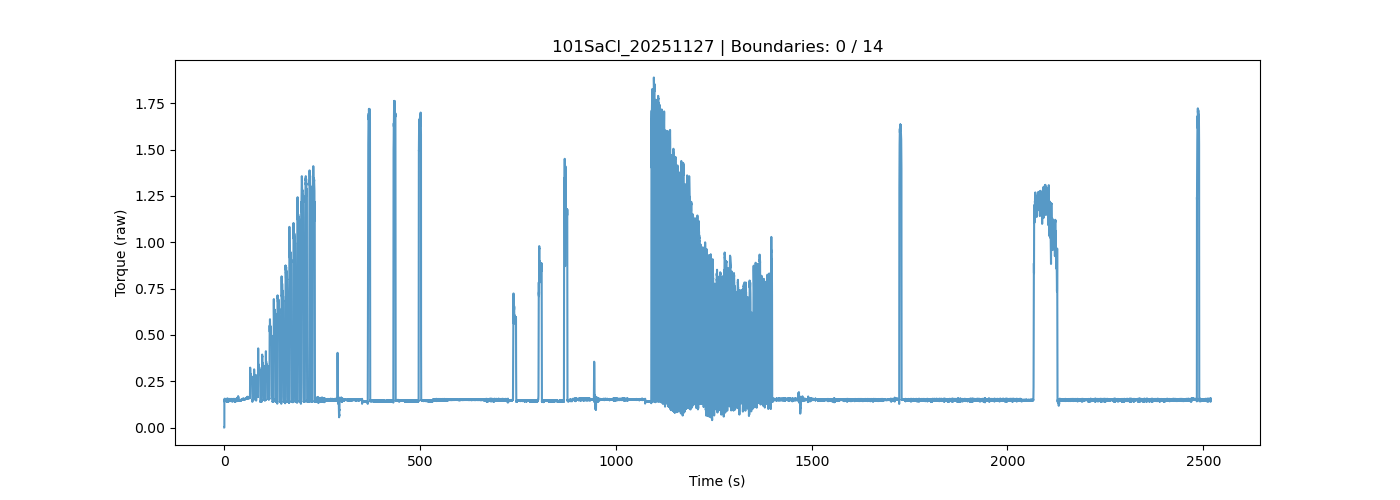

In [5]:
# 03a - MANUAL SEQ PICKER (torque-based)
%matplotlib widget

from sources import _03a_sequence_picker
importlib.reload(_03a_sequence_picker)

output_json_path = _03a_sequence_picker.run_sequence_manual_selection(
    ctx=CTX,
    seq_order=SEQ_ORDER,
    force_recompute=False,
)


In [7]:
# 03b - Apply SEQ labeling
%matplotlib inline
from sources import _03b_sequence_labeling
import importlib
importlib.reload(_03b_sequence_labeling)



master_index_grid, emg_compact_df, torque_compact_df = (
    _03b_sequence_labeling.run_apply_label_to_grid(
        ctx=CTX,
        seq_order=SEQ_ORDER,
        force_recompute=False,
    )
)

# update CTX with labeled versions
CTX["master_index_grid"] = master_index_grid
CTX["emg_compact_df"] = emg_compact_df
CTX["torque_compact_df"] = torque_compact_df

SEQ labels present: ['INIT', 'WU', 'REST0', 'MVC_REF', 'REST1', 'SVC_REF', 'REST2', 'EX_DYN', 'REST3', 'MVC_RECOV_DYN', 'REST4', 'EX_STA', 'REST5', 'MVC_RECOV_STA', 'END']
Applied boundaries: 14 Expected: 14
[03b_sequence_labeling] Updated caches with SEQ columns.


## 04. VOLUNTARY CONTRACTION DETECTION (VC)

[04_VC_Detection] Please adjust the knobs and reload this cell until each contraction is properly detected :
WU = variable, depends on the number of repetitions the subject needed to properly warm-up.
MVC_REF = MUST contain 3 or 4 repetitions. No more, no less.
SVC_REF = Always contain 3 repetitions, each growing in amplitude 
EX_DYN = Always contain 62 repetitions. Amplitude mostly decreasing as time goes 
MVC_RECOV = Both Recovery MVC is 1 rep.
EX_STA = 1 sustained rep (1 VC) of 60s
When set, move on to the next cell to commit into cache and apply the VC to the already existing DataFrame.


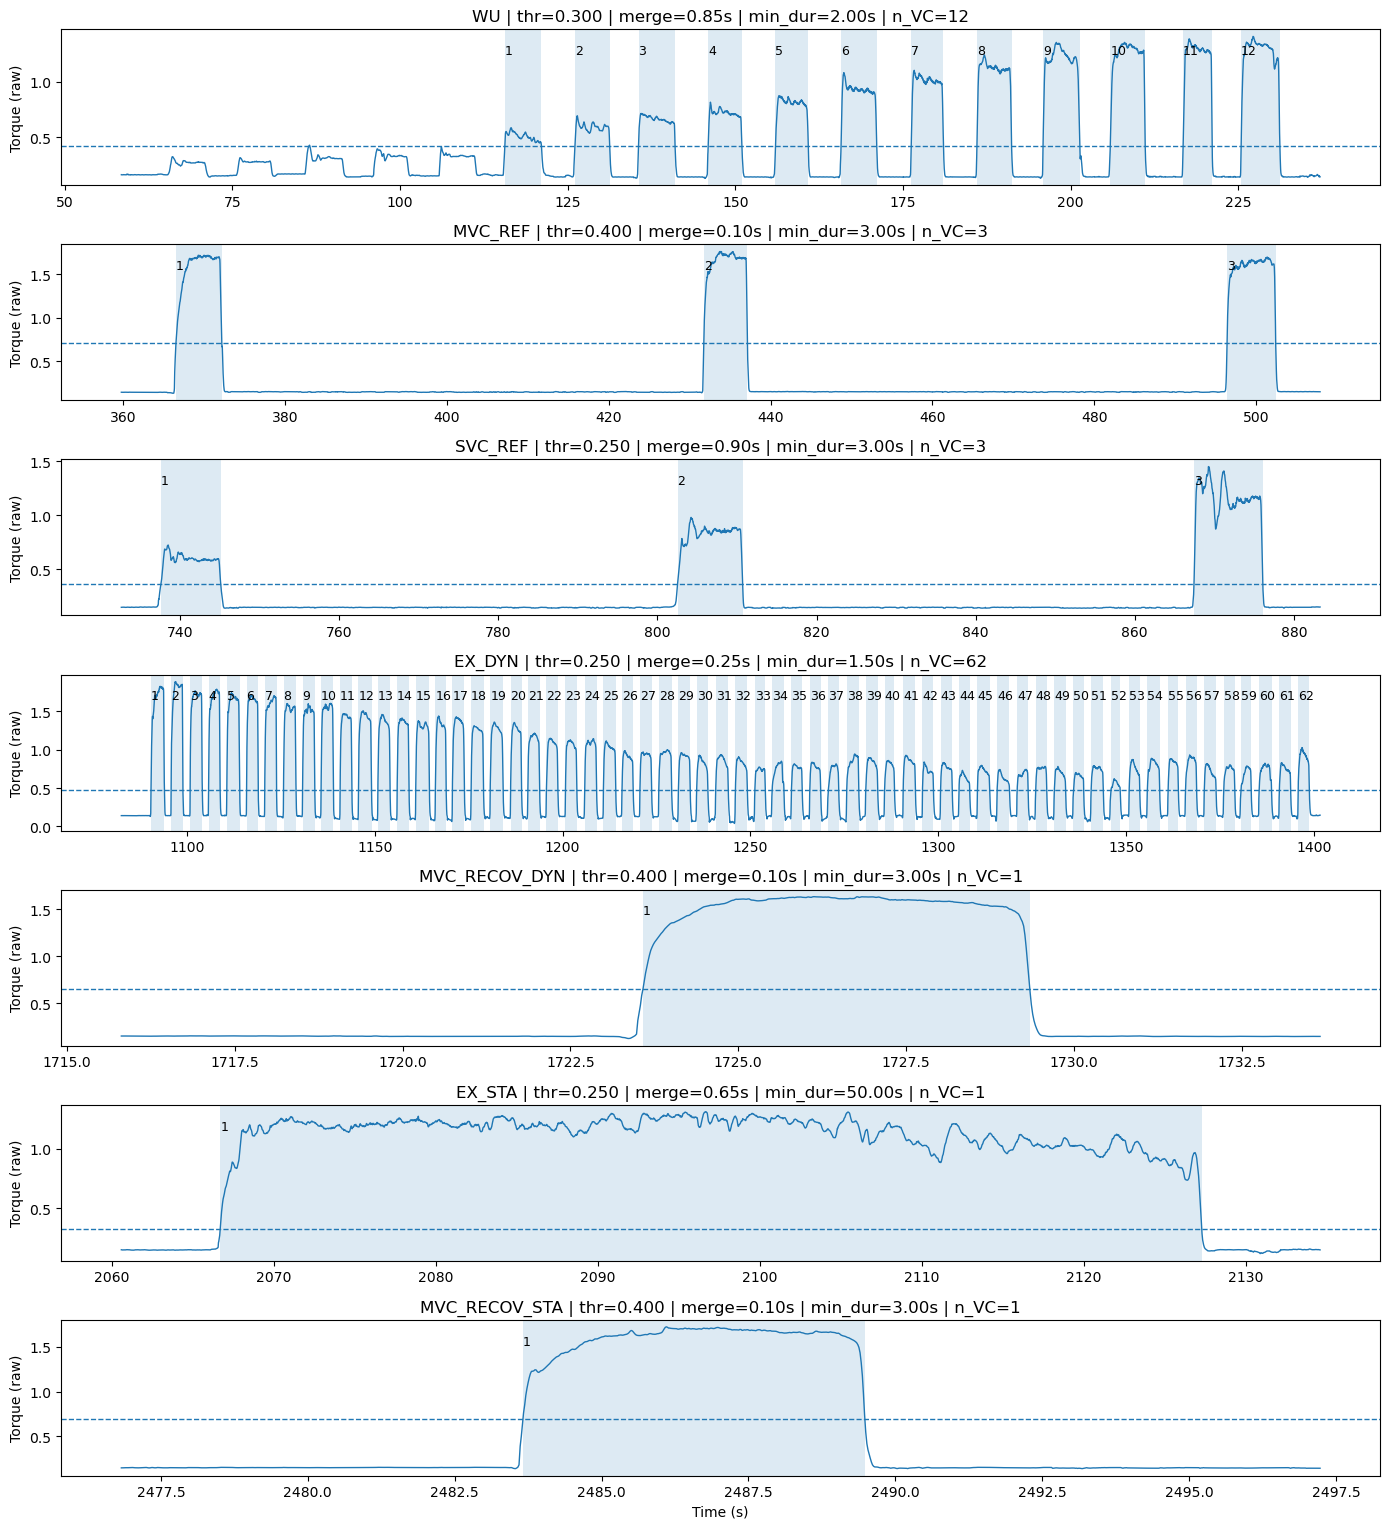

In [8]:
# 04 - VC DETECTION (TUNE)

from sources import _04_VC_detection
import importlib
importlib.reload(_04_VC_detection)

# Knobs by sequence for VC detection. Use these to optimize detection per sequence type, or leave uniform across sequences.
VC_KNOBS_BY_SEQ = {
    "WU":            {"thr_frac": 0.30, "merge_gap_s": 0.85, "min_dur_s": 2.00},
    "MVC_REF":       {"thr_frac": 0.40, "merge_gap_s": 0.10, "min_dur_s": 3.00},
    "SVC_REF":       {"thr_frac": 0.25, "merge_gap_s": 0.90, "min_dur_s": 3.00},
    "EX_DYN":        {"thr_frac": 0.25, "merge_gap_s": 0.25, "min_dur_s": 1.50},
    "MVC_RECOV_DYN": {"thr_frac": 0.40, "merge_gap_s": 0.10, "min_dur_s": 3.00},
    "EX_STA":        {"thr_frac": 0.25, "merge_gap_s": 0.65, "min_dur_s": 50.00},
    "MVC_RECOV_STA": {"thr_frac": 0.40, "merge_gap_s": 0.10, "min_dur_s": 3.00},
}


master_index_grid, torque_compact_df, emg_compact_df, vc_events_df = (
    _04_VC_detection.run_voluntary_contraction_detection(
        ctx=CTX,
        vc_knobs_by_seq=VC_KNOBS_BY_SEQ,
        force_recompute=True,
    )
)

CTX["master_index_grid"] = master_index_grid
CTX["torque_compact_df"] = torque_compact_df
CTX["emg_compact_df"] = emg_compact_df

In [9]:
# 04b - VC COMMIT (upgrade canonical 02 files)

paths = CTX["parquet_path"]  # get paths from CTX (set in 02_emg_import)

for key in ["CACHE_MASTER", "CACHE_EMG", "CACHE_TORQUE"]:
    assert key in paths, f"Missing parquet path in CTX: {key}"

for col in ["VC", "VC_count"]:
    assert col in master_index_grid.columns, f"master_index_grid missing '{col}'"

master_index_grid.to_parquet(paths["CACHE_MASTER"], index=False)
emg_compact_df.to_parquet(paths["CACHE_EMG"], index=False)
torque_compact_df.to_parquet(paths["CACHE_TORQUE"], index=False)

print("[04_VC_detection] VC committed: canonical 02 cache files upgraded.")

[04_VC_detection] VC committed: canonical 02 cache files upgraded.


## 5. BIA LOADER & SYNC

In [10]:
# 05a - BIA IMPORT

from sources import _05a_bia_import
import importlib
importlib.reload(_05a_bia_import)


bia2_compact_df, bia4_compact_df, bia2_freqs_hz, bia4_freqs_hz = (
    _05a_bia_import.run_bia_import(
        ctx=CTX,
        raw_bia_dir=RAW_BIA_DIR,
        ts_ref=ts_ref,
        force_recompute=False,
    )
)

CTX["bia2_compact_df"] = bia2_compact_df
CTX["bia4_compact_df"] = bia4_compact_df
CTX["bia2_freqs_hz"] = bia2_freqs_hz
CTX["bia4_freqs_hz"] = bia4_freqs_hz

[05a_bia_import] loading 2PT: 101SaCl_20251127_BIA_expe_Z2PT.pkl
[05a_bia_import] loading 4PT: 101SaCl_20251127_BIA_expe_Z4PT.pkl
[05a_bia_import] cached BIA files to cache directory. Force recomputing or delete cache files to re-run import.


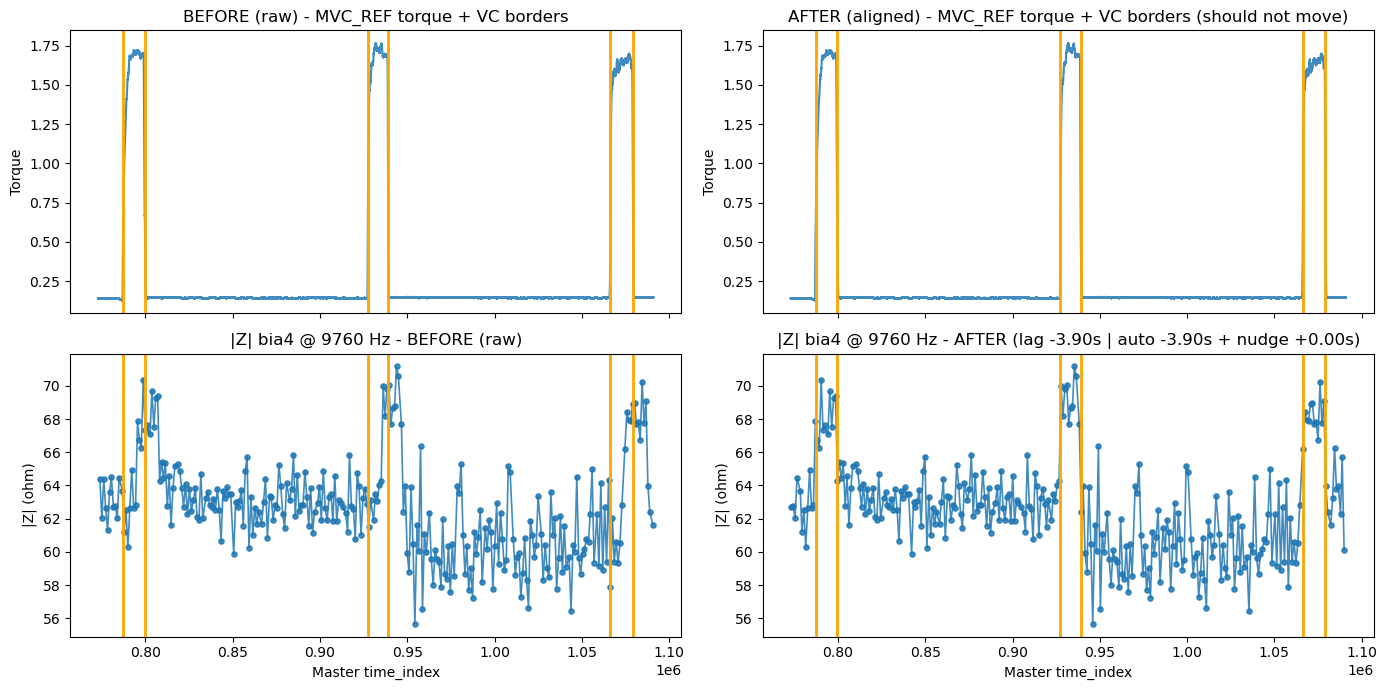

In [11]:
# 05b. BIA SYNC - TUNE (function-based)

# knobs - EDIT THOSE AND RERUN CELL UNTIL SYNC LOOKS GOOD

BIA_SYNC_LAG_MIN_S  = -5
BIA_SYNC_LAG_MAX_S  = 5
BIA_SYNC_MANUAL_NUDGE_S = -0

# reload 
import importlib
import sources._05b_bia_sync as bia_sync_mod
importlib.reload(bia_sync_mod)

bia2_compact_aligned_df, bia4_compact_aligned_df, bia_sync_qc_fig_out = bia_sync_mod.run_bia_sync(
    ctx=CTX,
    lag_min_s=BIA_SYNC_LAG_MIN_S,
    lag_max_s=BIA_SYNC_LAG_MAX_S,
    manual_nudge_s=BIA_SYNC_MANUAL_NUDGE_S,
    torque_col=CTX.get("TORQUE_COL", "torque_raw"),
    force_recompute=False,
)

# ctx for downstream
CTX["bia2_compact_aligned_df"] = bia2_compact_aligned_df
CTX["bia4_compact_aligned_df"] = bia4_compact_aligned_df


In [12]:
# 05b - BIA SYNC COMMIT (freeze current aligned data)


paths = CTX["parquet_path"]  # get paths from CTX 

for key in ["CACHE_BIA_2_ALIGNED", "CACHE_BIA_4_ALIGNED"]:
    assert key in paths, f"Missing parquet path in CTX: {key}"


bia2_compact_aligned_df.to_parquet(paths["CACHE_BIA_2_ALIGNED"], index=False)
bia4_compact_aligned_df.to_parquet(paths["CACHE_BIA_4_ALIGNED"], index=False)
pd.DataFrame({"freq_hz": bia2_freqs_hz}).to_parquet(paths["CACHE_BIA_2_FREQS"], index=False)
pd.DataFrame({"freq_hz": bia4_freqs_hz}).to_parquet(paths["CACHE_BIA_4_FREQS"], index=False)

print("[05b_bia_sync] BIA committed")




[05b_bia_sync] BIA committed


## 6. NIRS LOADER & SYNC

In [13]:
# 06a - NIRS IMPORT

from sources import _06a_nirs_import
import importlib
importlib.reload(_06a_nirs_import)

nirs_compact_df = _06a_nirs_import.run_nirs_import(
    ctx=CTX,
    raw_nirs_dir=RAW_NIRS_DIR,
    ts_ref=ts_ref,
    force_recompute=True,
)

CTX["nirs_compact_df"] = nirs_compact_df

[06a_nirs_import] Cache has been saved: 06a_nirs_compact.parquet


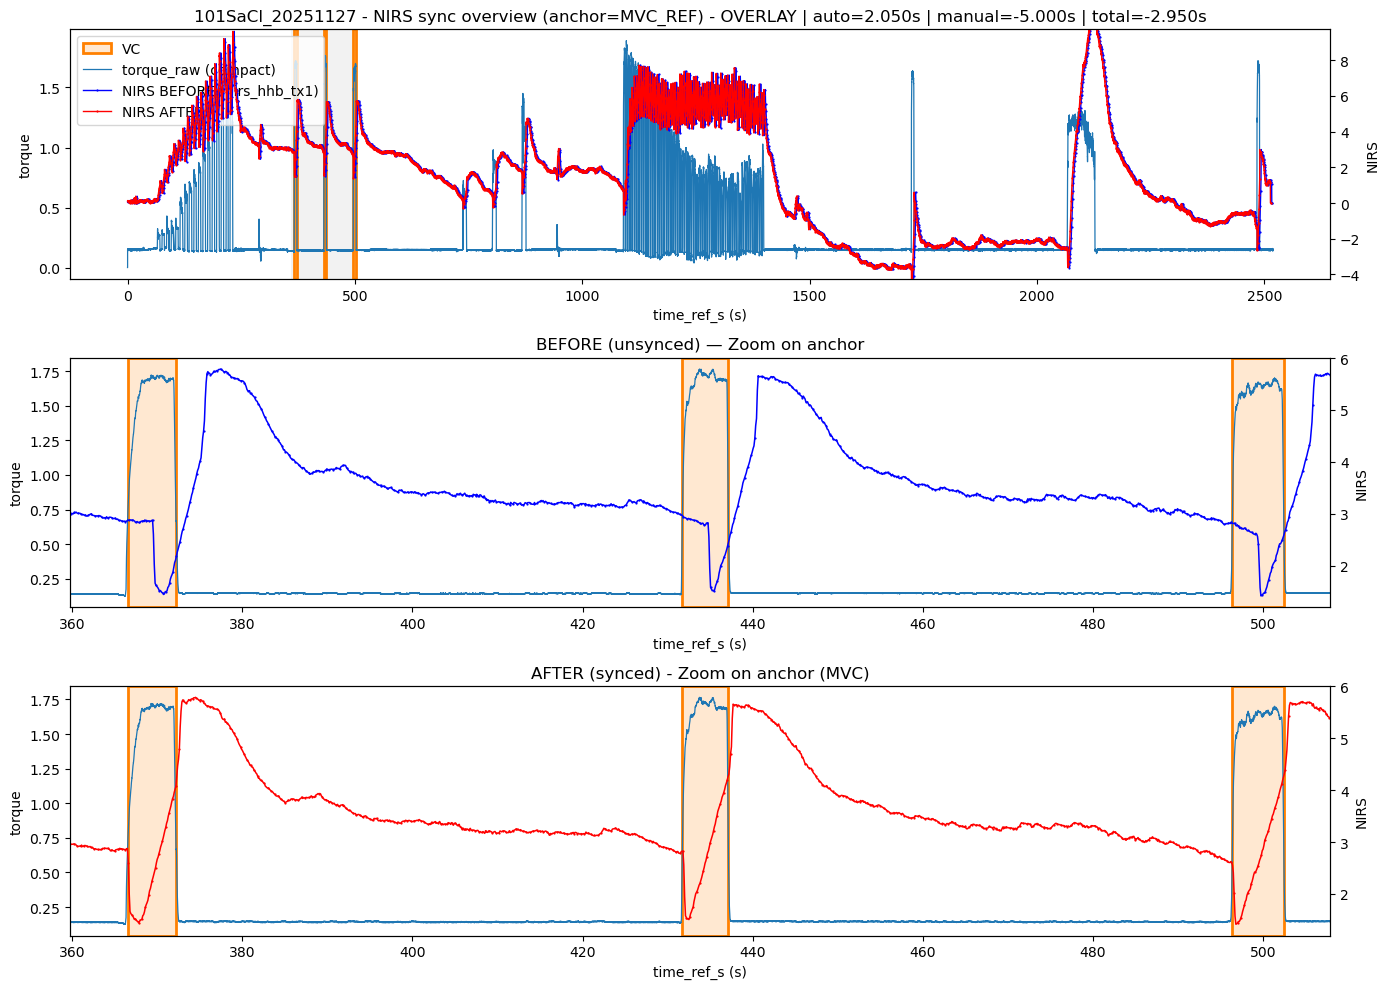

In [15]:
# 6b. NIRS SYNC - TUNE (function-based)

from sources import _06b_nirs_sync
import importlib
importlib.reload(_06b_nirs_sync)

# knobs - EDIT THOSE AND RERUN CELL UNTIL SYNC LOOKS GOOD
NIRS_SYNC_TARGET_SEQ = "MVC_REF"
NIRS_SYNC_SIGNAL_COL = "nirs_hhb_tx1" #current scoring method works with nirs_hhb_tx1 and with nirs_hbdiff_tx1. Avoid o2 & thb with current method or edit in _06b_nirs_sync.py.
NIRS_SYNC_LAG_MIN_S = -5
NIRS_SYNC_LAG_MAX_S = 5
NIRS_MANUAL_NUDGE_S = -5
NIRS_SYNC_FORCE_RECOMPUTE = False  # new: ignore cache without deleting parquet

nirs_compact_aligned_df, nirs_sync_qc_fig_out = _06b_nirs_sync.run_nirs_sync(
    ctx=CTX,
    nirs_signal_col=NIRS_SYNC_SIGNAL_COL,
    lag_min_s=NIRS_SYNC_LAG_MIN_S,
    lag_max_s=NIRS_SYNC_LAG_MAX_S,
    manual_nudge_s=NIRS_MANUAL_NUDGE_S,
    torque_col=CTX.get("TORQUE_COL", "torque_raw"),
    force_recompute=False,
)

# keep in ctx for downstream steps too
CTX["nirs_compact_aligned_df"] = nirs_compact_aligned_df

# optional: naming 
nirs_sync_qc_fig_name = f"06b_nirs_sync_tune_{CTX['RUN_ID']}.png"



In [16]:
# 06b - NIRS SYNC COMMIT (freeze current aligned data)

paths = CTX["parquet_path"]  # get paths from CTX 

for key in ["CACHE_NIRS_ALIGNED"]:
    assert key in paths, f"Missing parquet path in CTX: {key}"

nirs_compact_aligned_df.to_parquet(paths["CACHE_NIRS_ALIGNED"], index=False)

print(f"[06b_nirs_sync] data committed → {paths['CACHE_NIRS_ALIGNED'].name}")



[06b_nirs_sync] data committed → 06b_nirs_compact_aligned.parquet


## 7. MYOTON LOADER & SYNC

[07_myoton_import] loading: 101SaCl_20251127_Myoton.csv
[07_myoton_import] Cache has been saved : 07_myoton_compact.parquet. Force_recompute=True or deleting the file will trigger re-import and sync.


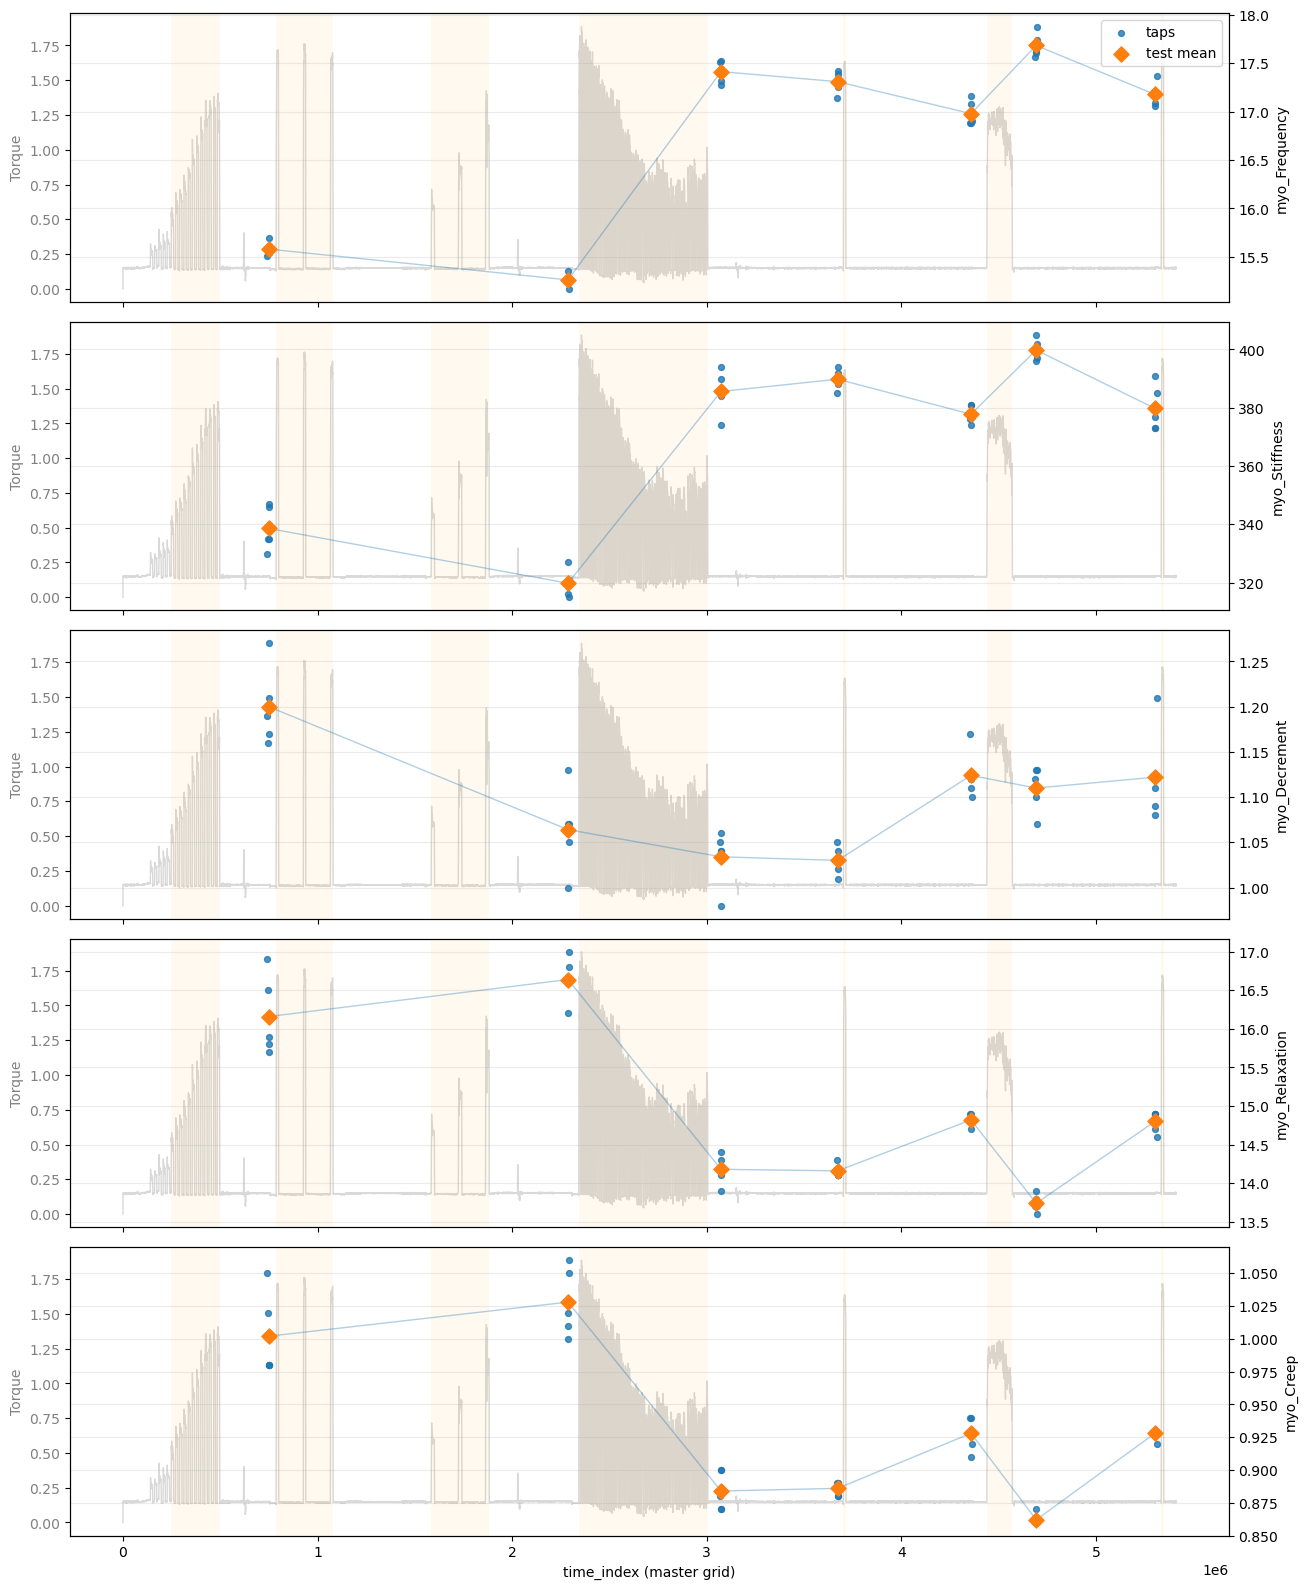

In [17]:
# 07 — MYOTON IMPORT (+ optional QC plot)

from sources import _07_myoton_import_sync
import importlib
importlib.reload(_07_myoton_import_sync)

myoton_compact_df, fig_myoton_qc = _07_myoton_import_sync.run_myoton_load_sync(
    ctx=CTX,
    raw_myoton_dir=RAW_MYOTON_DIR,
    ts_ref=ts_ref,
    force_recompute=False,
)

CTX["myoton_compact_df"] = myoton_compact_df

## 8. FINAL FULL QC PLOTS

In [ ]:
# 08 - FINAL QC CHECK (PLOTS + EXPORT)
%matplotlib inline

from sources import _08_final_quality_check
import importlib
importlib.reload(_08_final_quality_check)

#pick the plots you want to see in the final QC step (and export). Available plots are: "overview_emg_torque", "bia_time", "bia_nyquist", "nirs_tx", "myoton". Note that some plots may not be available for all runs, depending on data quality and processing outcomes. If a selected plot is not available, it will be skipped with a warning message.
#They do cache from actual cached filed up to this point rather than global variables so it's probably a smart idea to plot them, just to check. 
PLOT_SELECTION = ["overview_emg_torque", 
                  "bia_time", 
                  "bia_nyquist", 
                  "nirs_tx", 
                  "myoton"
                  ]  

qc_figs = _08_final_quality_check.run_final_qc(
    ctx=CTX,
    plot_selection=PLOT_SELECTION,
)

for fig in qc_figs:
    display(fig)


## 9. DATA EXPORT

In [ ]:
# 9a. APPEND DATA NEEDED FOR THE DATABASE 
# PLEASE MAKE SURE QC IS DONE PROPERLY ON THE RIGHT SET OF DATA BEFORE COMITTING THIS STEP.




#Run_id
# Period (before ?)
# state per sequence
# PP table somewhere else 

In [ ]:
# 9b. QC EXPORT (PDF)

from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

QC_EXPORT_ROOT = Path("results") / "QC_EXPORT"
QC_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

qc_pdf_path = QC_EXPORT_ROOT / f"QC_PLOT_EXPORT_{RUN_ID}.pdf"

with PdfPages(qc_pdf_path) as pdf:
    for fig in qc_figs:
        pdf.savefig(fig)

print(f"[QC EXPORT] PDF created → {qc_pdf_path.resolve()}")

# DATA EXPORT
import shutil


DATA_EXPORT_ROOT = Path("results") / "DATA_EXPORT" / RUN_ID
DATA_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

# 9c. DATA EXPORT (PARQUET)
PARQUET_EXPORT_LIST = [
    "01_participants.parquet",
    "02_emg_compact.parquet",
    "02_master_index_grid.parquet",
    "02_torque_compact.parquet",
    # "05_bia2_compact.parquet",
    "05a_bia2_freqs_hz.parquet",
    # "05_bia4_compact.parquet",
    "05a_bia4_freqs_hz.parquet",
    "05b_bia2_compact_aligned.parquet",
    "05b_bia4_compact_aligned.parquet",
    "06b_nirs_compact_aligned.parquet",
    "07_myoton_compact.parquet",
    #"02_metadata.parquet",
    #"04_vc_knobs_events.parquet",
]

## also print the columns inside the parquet selected for export, for quick reference
print("Parquet files selected for export and their columns:")
for fname in PARQUET_EXPORT_LIST:
    src = CACHE_DIR / fname
    if src.exists():
        df = pd.read_parquet(src)
        print(f"- {fname}: columns = {list(df.columns)}")
    else:
        print(f"- {fname}: NOT FOUND in cache, will fail export.")
        

# COPY

assert isinstance(CACHE_DIR, Path), "CACHE_DIR must be a pathlib.Path"
assert CACHE_DIR.exists(), f"CACHE_DIR not found: {CACHE_DIR}"

copied = 0
for fname in PARQUET_EXPORT_LIST:
    src = CACHE_DIR / fname
    assert src.exists(), f"Missing export file: {src}"

    dst = DATA_EXPORT_ROOT / fname
    shutil.copy2(src, dst)

    print(f"[DATA EXPORT] Copied → {dst}")
    copied += 1

assert copied > 0, "Nothing copied (PARQUET_EXPORT_LIST empty?)"
print(f"\n[DATA EXPORT COMPLETE] → {DATA_EXPORT_ROOT.resolve()}")



[QC EXPORT] PDF created → C:\Users\morga\Desktop\EUROMOV\AMSTROM_CAMPAIN\results\QC_EXPORT\QC_PLOT_EXPORT_101SaCl_20251127.pdf
Parquet files selected for export and their columns:
- 01_participants.parquet: columns = ['file', 'participant_id', 'dob', 'sex', 'height_cm', 'mass_kg', 'dominant_side', 'practice_level', 'patho_history', 'medication', 'run_number', 'mvc_ref', 'delsys_ts_init', 'comments']
- 02_emg_compact.parquet: columns = ['time_index', 'emg6', 'emg8', 'emg10', 'SEQ_index', 'SEQ', 'VC', 'VC_count']
- 02_master_index_grid.parquet: columns = ['time_index', 'time_ref_s', 'SEQ_index', 'SEQ', 'VC', 'VC_count']
- 02_torque_compact.parquet: columns = ['time_index', 'torque_raw', 'SEQ_index', 'SEQ', 'VC', 'VC_count']
- 05a_bia2_freqs_hz.parquet: columns = ['freq_hz']
- 05a_bia4_freqs_hz.parquet: columns = ['freq_hz']
- 05b_bia2_compact_aligned.parquet: columns = ['time_index', 'SEQ_index', 'VC', 'VC_count', 'bia2_time_on_master_s', 'bia2_R_ohm__f_4880Hz', 'bia2_Xc_ohm__f_4880Hz', 

In [20]:
# load and inspect all parquet files in the folder : C:\Users\morga\Desktop\EUROMOV\AMSTROM_CAMPAIN\results\DATA_EXPORT\101SaCl_20251127
DATA_EXPORT_ROOT = Path("results") / "DATA_EXPORT" / RUN_ID 
for parquet_file in DATA_EXPORT_ROOT.glob("*.parquet"):
    print(f"\n--- {parquet_file.name} ---")
    df = pd.read_parquet(parquet_file)
    print(df.head())
    header = df.columns
    print(f"Columns: {list(df.columns)}")


--- 01_participants.parquet ---
                          file participant_id        dob sex  height_cm  \
0  101SaCl_20251127_Infos.xlsx        101SaCl 2005-09-09   F      163.0   

   mass_kg dominant_side                                     practice_level  \
0     55.0             G  STAPS PF\nForce athlétique - 1 an - 1 à 3x / s...   

  patho_history medication  run_number  mvc_ref          delsys_ts_init  \
0           RAS        RAS        3222      231 2025-11-27 11:06:51.360   

   comments  
0       NaN  
Columns: ['file', 'participant_id', 'dob', 'sex', 'height_cm', 'mass_kg', 'dominant_side', 'practice_level', 'patho_history', 'medication', 'run_number', 'mvc_ref', 'delsys_ts_init', 'comments']

--- 02_emg_compact.parquet ---
   time_index  emg6  emg8  emg10  SEQ_index   SEQ  VC  VC_count
0           0   0.0   0.0    0.0          0  INIT   0         0
1           1   0.0   0.0    0.0          0  INIT   0         0
2           2   0.0   0.0    0.0          0  INIT   0      